In [2]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [8]:
fake_df = pd.read_csv("/Users/vishnumurali/Downloads/FakeNewsDetectionProject/Fake.csv")
true_df = pd.read_csv("/Users/vishnumurali/Downloads/FakeNewsDetectionProject/True.csv")

print(fake_df.head())
print(true_df.head())

                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept t

In [9]:
fake_df["label"] = 0
true_df["label"] = 1

print(fake_df.shape)
print(true_df.shape)

(23481, 5)
(21417, 5)


In [10]:
# Combine both datasets
df = pd.concat([fake_df, true_df], axis=0)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [11]:
# check data
print(df.info())
print(df["label"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None
label
0    23481
1    21417
Name: count, dtype: int64


In [12]:
# Create a text Column
df["combined_text"] = df["title"] + " " + df["text"]

df = df[["combined_text", "label"]]

df.head()

,combined_text,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0
1,Trump drops Steve Bannon from National Securit...,1
2,Puerto Rico expects U.S. to lift Jones Act shi...,1
3,OOPS: Trump Just Accidentally Confirmed He Le...,0
4,Donald Trump heads for Scotland to reopen a go...,1


In [13]:
# Clean up missing and duplicte values
df = df.dropna()
df = df.drop_duplicates()

print(df.shape)

(39105, 2)


In [14]:
# Clean up the text
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["combined_text"].apply(clean_text)

df.head()

,combined_text,label,clean_text
0,Ben Stein Calls Out 9th Circuit Court: Committ...,0,ben stein calls out th circuit court committed...
1,Trump drops Steve Bannon from National Securit...,1,trump drops steve bannon from national securit...
2,Puerto Rico expects U.S. to lift Jones Act shi...,1,puerto rico expects us to lift jones act shipp...
3,OOPS: Trump Just Accidentally Confirmed He Le...,0,oops trump just accidentally confirmed he leak...
4,Donald Trump heads for Scotland to reopen a go...,1,donald trump heads for scotland to reopen a go...


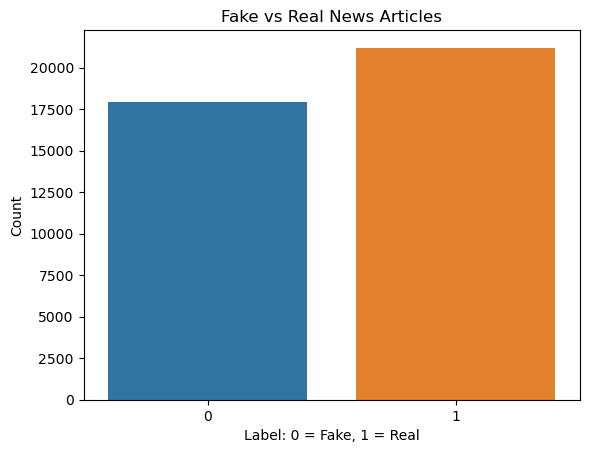

In [15]:
# Visualizations
sns.countplot(x="label", data=df)
plt.title("Fake vs Real News Articles")
plt.xlabel("Label: 0 = Fake, 1 = Real")
plt.ylabel("Count")
plt.show()

In [16]:
# Split into train and test data
X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(31284,)
(7821,)


In [17]:
# Tf-idf vectorization
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(31284, 5000)
(7821, 5000)


In [18]:
# Train a Naive Bayes Model
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

print("Naive Bayes Results")
print("Accuracy:", accuracy_score(y_test, nb_predictions))
print("Precision:", precision_score(y_test, nb_predictions))
print("Recall:", recall_score(y_test, nb_predictions))
print("F1 Score:", f1_score(y_test, nb_predictions))

Naive Bayes Results
Accuracy: 0.9368367216468483
Precision: 0.9442231075697212
Recall: 0.9402567094515752
F1 Score: 0.9422357343311506


In [19]:
# Train a Logistic Regression Model
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, lr_predictions))
print("Precision:", precision_score(y_test, lr_predictions))
print("Recall:", recall_score(y_test, lr_predictions))
print("F1 Score:", f1_score(y_test, lr_predictions))

Logistic Regression Results
Accuracy: 0.9879810765886715
Precision: 0.9845086705202312
Recall: 0.9936989498249709
F1 Score: 0.989082462253194


In [22]:
# Train a Random Forest Model
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_tfidf, y_train)

rf_predictions = rf_model.predict(X_test_tfidf)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, rf_predictions))
print("Precision:", precision_score(y_test, rf_predictions))
print("Recall:", recall_score(y_test, rf_predictions))
print("F1 Score:", f1_score(y_test, rf_predictions))

Random Forest Results
Accuracy: 0.9968034778161361
Precision: 0.9967350746268657
Recall: 0.9974329054842473
F1 Score: 0.9970838679575411


In [23]:
# Compare all 3 models to see which is the best and most accurate
results = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, lr_predictions),
        accuracy_score(y_test, rf_predictions)
    ],
    "Precision": [
        precision_score(y_test, nb_predictions),
        precision_score(y_test, lr_predictions),
        precision_score(y_test, rf_predictions)
    ],
    "Recall": [
        recall_score(y_test, nb_predictions),
        recall_score(y_test, lr_predictions),
        recall_score(y_test, rf_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, nb_predictions),
        f1_score(y_test, lr_predictions),
        f1_score(y_test, rf_predictions)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.936837,0.944223,0.940257,0.942236
1,Logistic Regression,0.987981,0.984509,0.993699,0.989082
2,Random Forest,0.996803,0.996735,0.997433,0.997084


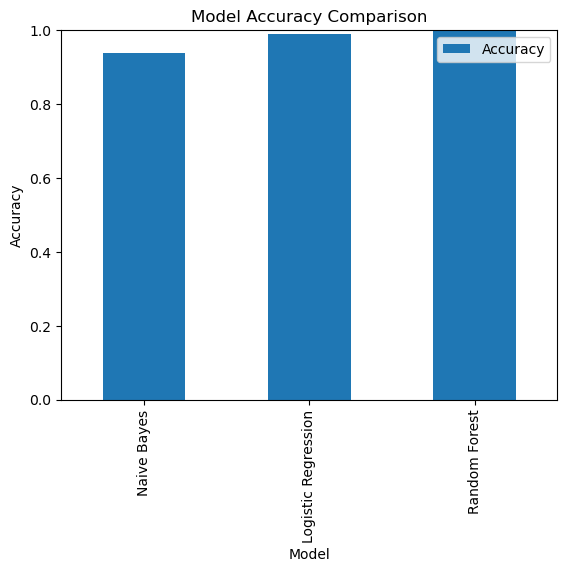

In [24]:
# Visualize Results on a Barchart
results.plot(x="Model", y="Accuracy", kind="bar")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

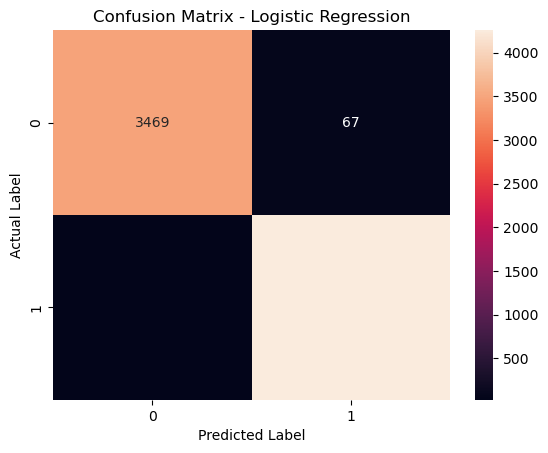

In [25]:
# Confusion Matrix for the best model
cm = confusion_matrix(y_test, lr_predictions)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [26]:
# Classification Report
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3536
           1       0.98      0.99      0.99      4285

    accuracy                           0.99      7821
   macro avg       0.99      0.99      0.99      7821
weighted avg       0.99      0.99      0.99      7821



In [29]:
sample_text =["The Federal Reserve announced interest rates will remain unchanged this month."]

sample_clean = [clean_text(sample_text[0])]
sample_tfidf = tfidf.transform(sample_clean)

prediction = lr_model.predict(sample_tfidf)

if prediction[0] == 0:
    print("Prediction: Fake News")
else:
    print("Prediction: Real News")

Prediction: Real News
